# Spam Email Dataset- Prediction Comparison Across Models

This notebook **trains** several **`rice_ml`** classifiers on **`datasets/spam_email_dataset.csv`**, localizes all results, evaluates them on a held-out test set, then summarizes the metrics across all models.

## Setup

We locate the repository root (folder that contains `src/`), add it to `sys.path`, and load **`compare_spam_models.py`** as a module so we can call **`run_comparison()`** — the same logic the CLI script uses.

In [5]:
import importlib.util
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
while not (_repo / "src").exists() and _repo != _repo.parent:
    _repo = _repo.parent
if not (_repo / "src").exists():
    raise FileNotFoundError("Could not find project src/ — open the notebook from the repo or examples/.")

_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

_script = _repo / "examples" / "compare_spam_models.py"
if not _script.is_file():
    _script = Path.cwd().resolve() / "compare_spam_models.py"

spec = importlib.util.spec_from_file_location("compare_spam_models", _script)
compare_spam = importlib.util.module_from_spec(spec)
spec.loader.exec_module(compare_spam)

FEATURES = compare_spam.FEATURES
TEST_SIZE = compare_spam.TEST_SIZE
RANDOM_STATE = compare_spam.RANDOM_STATE

## What gets evaluated

| Piece | Choice |
|--------|--------|
| **Data** | `examples/datasets/spam_email_dataset.csv` (loaded by the script next to that file) |
| **Features** | Five numeric columns used across your spam-focused supervised examples: word/link counts, suspicious link flag, attachments, sender reputation |
| **Target** | `label` (binary: spam vs. not) |
| **Split** | `train_test_split` with fixed `random_state` so every model sees the same train/test partition |
| **Scaling** | `standardize(X_train, X_test)` — mean and std from **training** data only |
| **Models** | Logistic regression, Perceptron (labels mapped to ±1 internally), decision tree, k-NN, random forest, multilayer perceptron, sigmoid neural network — exact hyperparameters are defined in `compare_spam_models.py` |

Training each model can take a while (especially random forest and neural nets), so we will use **`QUICK = True`** to obtain the summary.

In [6]:
# Faster smoke run: fewer epochs / fewer trees. Set False for full training (matches CLI default).
QUICK = False

results_df = compare_spam.run_comparison(quick=QUICK)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,LogisticRegression,0.8045,0.7750,0.7134,0.7429,0.8844
1,Perceptron,0.7470,0.6702,0.7109,0.6900,NaN
2,DecisionTree,0.7465,1.0000,0.3598,0.5292,NaN
3,KNearestNeighbors (k=5),0.7835,0.7224,0.7361,0.7292,NaN
4,RandomForestClassifier,0.7465,1.0000,0.3598,0.5292,NaN
5,MultiLayerPerceptron,0.7955,0.7763,0.6793,0.7246,NaN
6,SigmoidNeuralNetwork,0.8045,0.7750,0.7134,0.7429,0.8818


## Reading the results

All metrics are computed on the **test** set only.

- **Accuracy** — Fraction of emails labeled correctly.
- **Precision** — Among emails predicted as spam, how many were actually spam (binary average: positive class = spam).
- **Recall** — Among true spam emails, how many we caught.
- **F1** — Harmonic mean of precision and recall; useful when classes are imbalanced.
- **ROC-AUC** — Model ranking quality from predicted probabilities; **only** filled for models that expose `predict_proba` in this benchmark (logistic regression and sigmoid neural network). Other rows show a missing value.

High precision with low recall often means the model is conservative about marking spam; the opposite pattern can mean many false alarms.

In [7]:
n_rows = results_df.attrs.get("dataset_rows", "?")
print(f"Dataset rows: {n_rows}")
print(f"Features: {FEATURES}")
print(f"Split: test_size={TEST_SIZE}, random_state={RANDOM_STATE}")
print("Scaling: standardize(X_train, X_test) using training statistics.")

Dataset rows: 10000
Features: ['num_words', 'num_links', 'has_suspicious_link', 'num_attachments', 'sender_reputation_score']
Split: test_size=0.2, random_state=42
Scaling: standardize(X_train, X_test) using training statistics.


## Comparing Accuracy and F1 Scores

Comparing **Accuracy** and **F1** across models on the test set with a simple horizontal bar chart. 

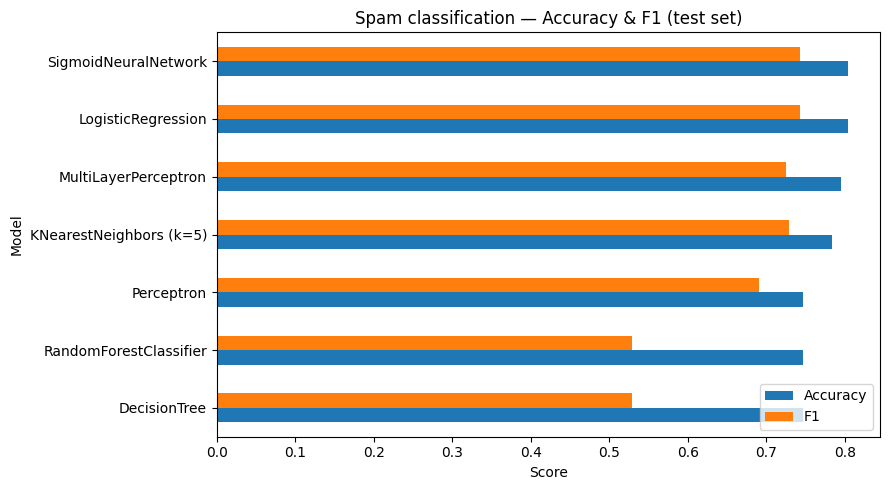

In [8]:
try:
    import matplotlib.pyplot as plt

    plot_df = results_df.set_index("Model")[["Accuracy", "F1"]].sort_values("Accuracy")
    ax = plot_df.plot(
        kind="barh",
        figsize=(9, 5),
        title="Spam classification — Accuracy & F1 (test set)",
    )
    ax.set_xlabel("Score")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available; skipping chart.")

From our results, we can infer that the Logistic Regression and Standard Neural Network models perform the best on the Spam Email Dataset with the highest accuracy and F-1 scores. The Decision Tree and Random Forest Classifier models also display high precision, though the low recall suggests conservative labeling. The K-Nearest-Neighbors model, which resulted in the highest recall while maintaining a decent accuracy score, is also a valid option for use on the spam dataset in email applications, since it displays the ability to flag more spam without a large increase in error.